In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv(r'D:\kathan\python_codes\7th sem\ML lab\ML-lab\dataset\bank_transactions.csv')

In [4]:
df.columns = df.columns.str.strip()
df.head()


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [6]:
print(df.columns.tolist())

['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)']


In [7]:
if 'TransactionAmount (INR)' in df.columns:
    df.rename(columns={'TransactionAmount (INR)':'TransactionAmount'}, inplace=True)


In [8]:
df.dropna()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


In [9]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce', dayfirst=True)
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'], errors='coerce')
df['CustAccountBalance'] = pd.to_numeric(df['CustAccountBalance'], errors='coerce')

C:\Users\Kathan Vyas\AppData\Local\Temp\ipykernel_10600\3854696575.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
C:\Users\Kathan Vyas\AppData\Local\Temp\ipykernel_10600\3854696575.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce', dayfirst=True)


In [10]:
# Fix obvious DOB issues (sometimes year is +100 due to anonymization) - common trick in similar notebooks
today = pd.Timestamp('today')
mask_future_dob = df['CustomerDOB'] > today
df.loc[mask_future_dob, 'CustomerDOB'] = df.loc[mask_future_dob, 'CustomerDOB'] - pd.DateOffset(years=100)

# Age
df['Age'] = ((today - df['CustomerDOB']).dt.days // 365).astype('Int64')

In [11]:
# Transaction hour/day
# if TransactionTime is provided as integer (e.g., 1345), adapt:
if 'TransactionTime' in df.columns:
    try:
        df['Hour'] = pd.to_datetime(df['TransactionTime'].astype(str).str.zfill(4), format='%H%M').dt.hour
    except:
        # else use timestamp hour
        df['Hour'] = df['TransactionDate'].dt.hour
else:
    df['Hour'] = df['TransactionDate'].dt.hour

df['Weekday'] = df['TransactionDate'].dt.day_name()

# drop duplicates / obviously bad rows
df = df.drop_duplicates(subset=['TransactionID'])
df = df[df['TransactionAmount'].notna() & df['TransactionDate'].notna()]


In [12]:
# snapshot (reference) date for recency = max date + 1 day
snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency_days = ('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('TransactionID', 'count'),
    Monetary = ('TransactionAmount', 'sum')
).reset_index()

# RFM scoring (quintiles). Recency: lower days => better (higher score)
rfm['R_score'] = pd.qcut(rfm['Recency_days'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score']*100 + rfm['F_score']*10 + rfm['M_score']
rfm.head()


,CustomerID,Recency_days,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,C1010011,75,2,5106.0,5,5,5,555
1,C1010012,118,1,1499.0,2,1,4,214
2,C1010014,155,2,1455.0,2,5,4,254
3,C1010018,86,1,30.0,4,1,1,411
4,C1010024,114,1,5000.0,3,1,5,315


In [13]:
# Peak hours
hourly = df.groupby('Hour').agg(Transactions=('TransactionID','count'), TotalAmt=('TransactionAmount','sum')).reset_index()
# Weekday pattern
weekday = df.groupby('Weekday').agg(Transactions=('TransactionID','count'), TotalAmt=('TransactionAmount','sum')).reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

# Transaction amount distribution / large outliers
desc = df['TransactionAmount'].describe(percentiles=[.5,.75,.9,.95,.99])
top_outliers = df.nlargest(int(len(df)*0.001), 'TransactionAmount')  # top 0.1%

# churn proxy: customers with high recency days (inactive), decreasing frequency (need time series)
churn_candidates = rfm[rfm['Recency_days'] > 180]  # example rule: no activity >6 months


In [14]:
# prepare per-customer aggregated features
agg = df.groupby('CustomerID').agg(
    Frequency=('TransactionID','count'),
    Monetary=('TransactionAmount','sum'),
    AvgTxn=('TransactionAmount','mean'),
    Recency_days=('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    LastTransactionDate=('TransactionDate', 'max'),
    CustAccountBalance=('CustAccountBalance','mean')  # or last
).reset_index()

# merge demographic (e.g., Age, Gender, Location)
demo = df[['CustomerID','Age','CustGender','CustLocation']].drop_duplicates(subset=['CustomerID'])
cust = agg.merge(demo, on='CustomerID', how='left')

# encode gender and fillna
cust['CustGender'] = cust['CustGender'].fillna('U')
cust = pd.get_dummies(cust, columns=['CustGender'], drop_first=True)


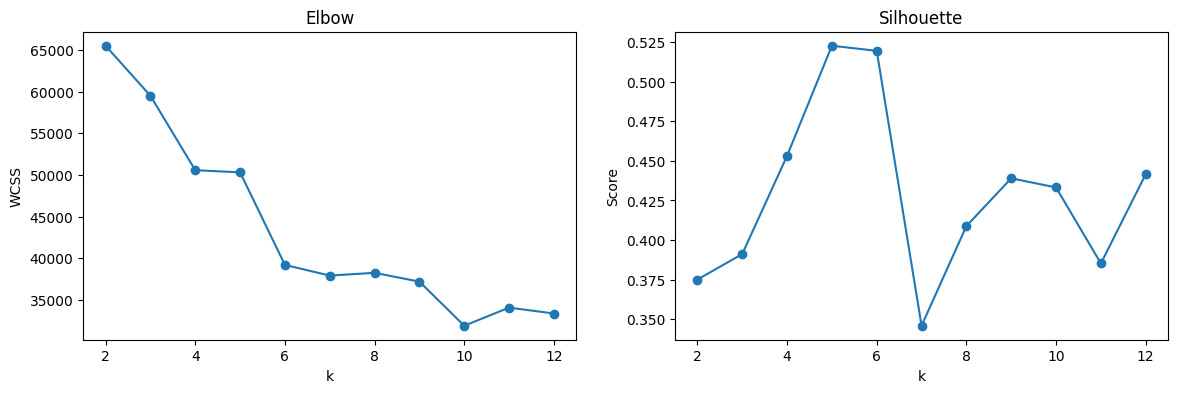

Best k by silhouette: 5


In [17]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X_sample = resample(X_scaled, n_samples=10000, random_state=42)

wcss = []; sil = []
K_range = range(2, 13)

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000).fit(X_sample)
    wcss.append(kmeans.inertia_)
    sil.append(silhouette_score(X_sample, kmeans.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(K_range, wcss, '-o'); ax[0].set_title('Elbow'); ax[0].set_xlabel('k'); ax[0].set_ylabel('WCSS')
ax[1].plot(K_range, sil, '-o'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Score')
plt.show()

best_k = K_range[int(np.argmax(sil))]
print("Best k by silhouette:", best_k)


In [18]:
k = best_k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_scaled)
cust['cluster'] = kmeans.labels_

# profile clusters
profile = cust.groupby('cluster')[features].agg(['count','mean','median']).T
print(profile)

# get top characteristics per cluster
cluster_summary = cust.groupby('cluster').agg({
    'Frequency':'mean','Monetary':'mean','AvgTxn':'mean','Recency_days':'mean','CustAccountBalance':'mean'
}).reset_index()
cluster_summary


cluster                                0             1              2  \
Frequency          count   736594.000000  4.123000e+03  142610.000000   
                   mean         1.000000  1.243997e+00       2.143987   
                   median       1.000000  1.000000e+00       2.000000   
Monetary           count   736594.000000  4.123000e+03  142610.000000   
                   mean      1272.434519  7.327327e+04    2869.478356   
                   median     454.000000  5.679000e+04    1410.000000   
AvgTxn             count   736594.000000  4.123000e+03  142610.000000   
                   mean      1272.434519  6.370520e+04    1336.306425   
                   median     454.000000  5.000000e+04     659.500000   
Recency_days       count   736594.000000  4.123000e+03  142610.000000   
                   mean       137.190355  1.261271e+02      91.405259   
                   median     112.000000  1.090000e+02      93.000000   
CustAccountBalance count   734943.000000  4.110000e

,cluster,Frequency,Monetary,AvgTxn,Recency_days,CustAccountBalance
0,0,1.000000,1272.434519,1272.434519,137.190355,1.095536e+05
1,1,1.243997,73273.274817,63705.198154,126.127092,1.171333e+06
2,2,2.143987,2869.478356,1336.306425,91.405259,1.141448e+05
3,3,1.162220,2319.721942,2130.635267,130.064034,3.245603e+04
4,4,1.000000,32500.000000,32500.000000,62.000000,5.005000e+04


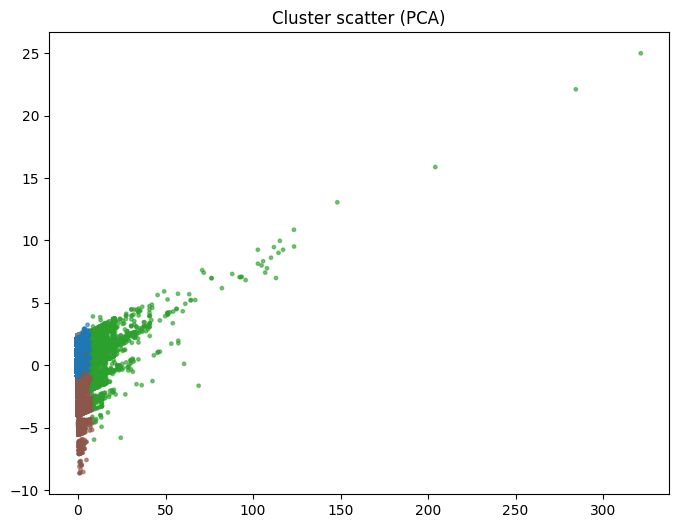

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
cust['PC1'] = pcs[:,0]; cust['PC2'] = pcs[:,1]
plt.figure(figsize=(8,6))
plt.scatter(cust['PC1'], cust['PC2'], c=cust['cluster'], cmap='tab10', s=6, alpha=0.6)
plt.title('Cluster scatter (PCA)')
plt.show()


In [20]:
loc = df.groupby('CustLocation').agg(
    Transactions=('TransactionID','count'),
    TotalAmt=('TransactionAmount','sum'),
    UniqueCustomers=('CustomerID','nunique')
).reset_index().sort_values('Transactions', ascending=False)

# top 20 cities/states
loc.head(20)


,CustLocation,Transactions,TotalAmt,UniqueCustomers
5268,MUMBAI,103595,1.796861e+08,101729
5792,NEW DELHI,84928,1.607059e+08,83564
772,BANGALORE,81555,1.184248e+08,80347
3083,GURGAON,73818,1.120947e+08,72856
2075,DELHI,71019,1.062249e+08,70067
5888,NOIDA,32784,4.446343e+07,32570
1603,CHENNAI,30009,4.463782e+07,29823
6719,PUNE,25851,3.959035e+07,25710
3394,HYDERABAD,23049,3.617739e+07,22929
8386,THANE,21505,2.715810e+07,21404


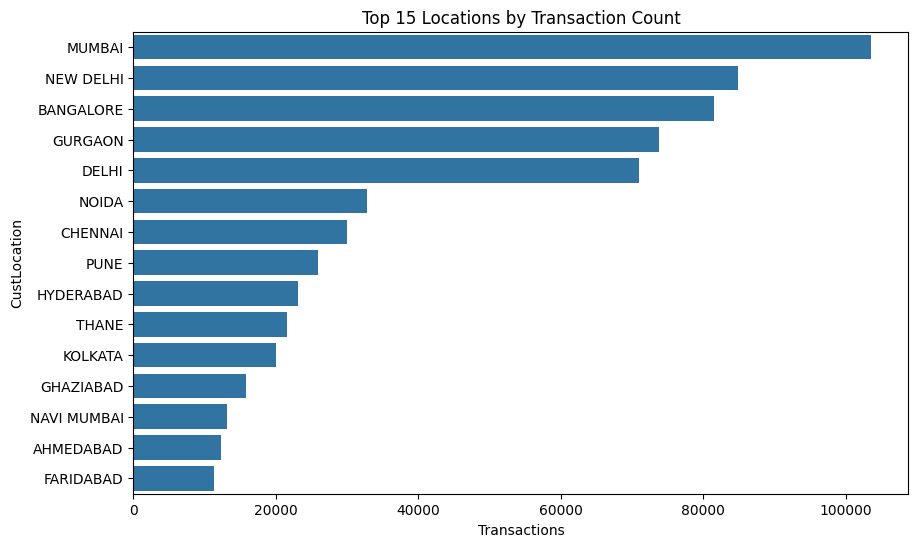

In [21]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=loc.head(15), x='Transactions', y='CustLocation')
plt.title('Top 15 Locations by Transaction Count')
plt.show()


In [ ]:
# 1) pick subset
top_n = 100000
top_idx = cust.sort_values('Monetary', ascending=False).head(top_n).index
X_sub = X_scaled[top_idx, :]

# 2) exact kNN in batch
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=11, metric='cosine', n_jobs=-1).fit(X_sub)
distances, indices = nbrs.kneighbors(X_sub)
rows, cols, weights = [], [], []
for i in range(X_sub.shape[0]):
    for j, dist in zip(indices[i,1:], distances[i,1:]):  # skip self
        rows.append(i); cols.append(j); weights.append(1 - dist)

# 3) build igraph
import igraph as ig
edges = list(zip(rows, cols))
g = ig.Graph(n=top_n, edges=edges, directed=False)
g.es['weight'] = weights

# 4) community detection
partition = g.community_multilevel(weights=g.es['weight'])
cust_sub = cust.iloc[top_idx].copy()
cust_sub['community'] = partition.membership
cust_sub.groupby('community').agg({'CustomerID':'count','Monetary':'mean'}).sort_values('CustomerID', ascending=False).head()
